<a href="https://colab.research.google.com/github/ugurba/Balci/blob/main/Prediction_Bitcoin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
!pip install yfinance
import yfinance as yf

print("attend zeuuubiii...")
df = yf.download("BTC-USD", period="1y")

print((df.head))

attend zeuuubiii...


/tmp/ipython-input-3212758802.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("BTC-USD", period="1y")
[*********************100%***********************]  1 of 1 completed

<bound method NDFrame.head of Price              Close           High           Low           Open  \
Ticker           BTC-USD        BTC-USD       BTC-USD        BTC-USD   
Date                                                                   
2025-02-04  97871.820312  101745.617188  96208.109375  101398.718750   
2025-02-05  96615.445312   99113.210938  96174.828125   97878.007812   
2025-02-06  96593.296875   99168.609375  95707.351562   96610.640625   
2025-02-07  96529.085938  100154.140625  95653.882812   96581.320312   
2025-02-08  96482.453125   96877.804688  95702.492188   96533.257812   
...                  ...            ...           ...            ...   
2026-01-31  78621.117188   84136.921875  75815.882812   84126.500000   
2026-02-01  76974.445312   79322.609375  75698.898438   78626.125000   
2026-02-02  78688.765625   79258.609375  74551.335938   76968.875000   
2026-02-03  75633.546875   79118.851562  72897.140625   78693.507812   
2026-02-04  72898.265625   76745.5

In [13]:
df = df[['Close']]
print(df.head())

Price              Close
Ticker           BTC-USD
Date                    
2025-02-04  97871.820312
2025-02-05  96615.445312
2025-02-06  96593.296875
2025-02-07  96529.085938
2025-02-08  96482.453125


In [14]:
# On crée la cible (y) en décalant les prix de 1 jour vers le passé
# Le prix de demain vient se mettre en face de la ligne d'aujourd'hui
df['Prediction'] = df['Close'].shift(-1)

print(df.tail())

Price              Close    Prediction
Ticker           BTC-USD              
Date                                  
2026-01-31  78621.117188  76974.445312
2026-02-01  76974.445312  78688.765625
2026-02-02  78688.765625  75633.546875
2026-02-03  75633.546875  72898.265625
2026-02-04  72898.265625           NaN


In [16]:
df = df.dropna()
print(df.tail())

Price              Close    Prediction
Ticker           BTC-USD              
Date                                  
2026-01-30  84128.656250  78621.117188
2026-01-31  78621.117188  76974.445312
2026-02-01  76974.445312  78688.765625
2026-02-02  78688.765625  75633.546875
2026-02-03  75633.546875  72898.265625


In [18]:
X = df[['Close']]
y = df['Prediction']

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

print("Jours d'entrainement : ", len(X_train))
print("Jours de Test : ", len(X_test))

Jours d'entrainement :  292
Jours de Test :  73


In [21]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [22]:
predictions = model.predict(X_test)

In [25]:
series = pd.Series(data=predictions, index=X_test.index)
print(series)

Date
2025-11-23    86987.552027
2025-11-24    88433.773715
2025-11-25    87517.352501
2025-11-26    90651.926279
2025-11-27    91408.816037
                  ...     
2026-01-30    84346.505804
2026-01-31    78911.619953
2026-02-01    77286.670302
2026-02-02    78978.376000
2026-02-03    75963.460450
Length: 73, dtype: float64


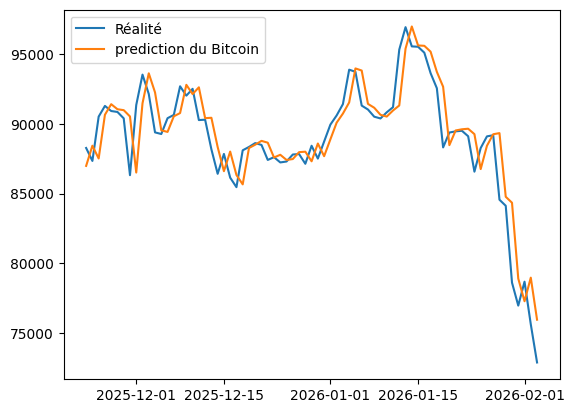

In [26]:
import matplotlib.pyplot as plt

plt.plot(y_test, label="Réalité")
plt.plot(series, label="prediction du Bitcoin")
plt.legend()
plt.show()

In [27]:
print(model.score(X_test, y_test))

0.8077966622147861
